# Examen Práctico Topicos de Big Data - 1er Parcial

Tópicos de Big Data
Instrucciones generales

Este notebook es tu entregable. Complétalo en orden, sin borrar los enunciados.
Al final debes subir este archivo (.ipynb) al repositorio de GitHub del curso, en la carpeta correspondiente a tu nombre/usuario.
Se evaluará tanto el código (que corra sin errores, de arriba hacia abajo) como tus interpretaciones escritas en las celdas de texto marcadas como "Interpretación".
Cada quien trabaja con un dataset distinto, asignado por la profesora. No copies celdas de un compañero con un dataset diferente: aunque las preguntas se parecen, los datos y las columnas no son las mismas.

# 0. Datos del alumno
Completa la siguiente celda con tus datos y el nombre del dataset que te fue asignado.

In [1]:
# --- COMPLETA CON TUS DATOS ---
NOMBRE = "Osmar"            # Tu nombre completo
MATRICULA = "81739"         # Tu matrícula o número de cuenta
DATASET_ASIGNADO = "PIB"  # Debe ser uno de: "alcohol", "migracion", "desnutricion", "pib", "homicidios"

print(f"Alumno: {NOMBRE}")
print(f"Matrícula: {MATRICULA}")
print(f"Dataset asignado: {DATASET_ASIGNADO}")


Alumno: Osmar
Matrícula: 81739
Dataset asignado: PIB


# 1. Configuración del entorno virtual (Visual Studio Code)
Antes de instalar librerías directamente en tu sistema, es una buena práctica crear un entorno virtual exclusivo para este examen. Esto evita conflictos de versiones con otros proyectos y hace que tu entorno de trabajo sea reproducible.

Requisitos previos en VS Code: ten instaladas las extensiones oficiales "Python" y "Jupyter" (ambas de Microsoft), disponibles en la pestaña de Extensiones (ícono de cuadritos en la barra lateral izquierda, o Ctrl+Shift+X / Cmd+Shift+X).

Abre una terminal dentro de VS Code (menú Terminal → New Terminal, o Ctrl+ñ/Ctrl+`) y verifica que estés ubicado en la carpeta de tu repositorio del curso (donde vas a guardar este notebook).

# 1. Crear el entorno virtual (se creará una carpeta llamada ".venv")
python -m venv .venv

# 2. Activar el entorno virtual
.venv\Scripts\Activate.ps1

# Si PowerShell bloquea la ejecución de scripts, ejecuta una sola vez:
#   Set-ExecutionPolicy -Scope CurrentUser RemoteSigned
# y vuelve a intentar activar el entorno.

# 3. Instalar las librerías necesarias
pip install pandas numpy ipykernel matplotlib requests

In [3]:
import sys
print(sys.executable)
# Debe mostrar una ruta dentro de tu carpeta "venv" (o de tu entorno "examen-bigdata" si usas conda).
# Si muestra la ruta de tu instalacion global de Python, regresa al paso anterior
# y selecciona el kernel correcto antes de continuar.


c:\Users\osmar\AppData\Local\Python\pythoncore-3.14-64\python.exe


# 2. Configuración y carga de datos
La siguiente celda no se modifica. Contiene la configuración de los 5 datasets posibles del examen. A partir de tu variable DATASET_ASIGNADO de la celda anterior, el notebook cargará automáticamente el dataset y los metadatos que te corresponden.

In [16]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

DATASET_ASIGNADO = "pib"
# --- NO MODIFICAR: configuración de los 5 datasets del examen ---
DATASETS = {
    "pib": {
        "csv": "https://ourworldindata.org/grapher/gdp-per-capita-worldbank-constant-usd.csv?v=1&csvType=full&useColumnShortNames=true",
        "meta": "https://ourworldindata.org/grapher/gdp-per-capita-worldbank-constant-usd.metadata.json?v=1&csvType=full&useColumnShortNames=true",
        "valor_col": "ny_gdp_pcap_kd",
        "filtro_paises": "code",
        "descripcion": "PIB per capita (dolares constantes de 2015)",
        "unidad": "USD",
    }
}

assert DATASET_ASIGNADO in DATASETS, (
    "DATASET_ASIGNADO debe ser uno de: " + ", ".join(DATASETS.keys())
)

config = DATASETS[DATASET_ASIGNADO]
print(f"Cargando dataset: {DATASET_ASIGNADO}")
print(f"Descripcion: {config['descripcion']} ({config['unidad']})")


Cargando dataset: pib
Descripcion: PIB per capita (dolares constantes de 2015) (USD)


In [17]:
df = pd.read_csv(
    config["csv"],
    storage_options={'User-Agent': 'Our World In Data data fetch/1.0'}
)

metadata = requests.get(config["meta"]).json()

df = df.rename(columns={config["valor_col"]: "valor"})

In [18]:
df.head(25)

,entity,code,year,valor
0,Afghanistan,AFG,2000,308.31827
1,Afghanistan,AFG,2001,277.11804
2,Afghanistan,AFG,2002,338.13998
3,Afghanistan,AFG,2003,346.07162
4,Afghanistan,AFG,2004,338.63727
5,Afghanistan,AFG,2005,363.64014
6,Afghanistan,AFG,2006,367.75830
7,Afghanistan,AFG,2007,410.75772
8,Afghanistan,AFG,2008,417.64728
9,Afghanistan,AFG,2009,488.83066


# 3. Exploración inicial
Antes de responder las preguntas de análisis, explora el dataset: tipos de datos, dimensiones, valores nulos y estadísticas descriptivas básicas.

In [19]:
# Forma del dataset (filas, columnas)
df.shape

(12384, 4)

In [ ]:
# Tipos de datos e informacion general
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 12384 entries, 0 to 12383
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   entity  12384 non-null  str    
 1   code    12384 non-null  str    
 2   year    12384 non-null  int64  
 3   valor   12384 non-null  float64
dtypes: float64(1), int64(1), str(2)
memory usage: 387.1 KB


In [ ]:
# Estadisticas descriptivas de la columna 'valor'
df['valor'].describe()

count     12384.000000
mean      12434.415310
std       19221.293985
min         122.678900
25%        1370.694600
50%        4089.543600
75%       16127.642000
max      247170.110000
Name: valor, dtype: float64

In [22]:
# Conteo de valores nulos por columna
df.isnull().sum()

entity    0
code      0
year      0
valor     0
dtype: int64

Interpretación (2-3 líneas): ¿qué observas sobre los valores nulos, el rango de años y el tipo de variable con la que vas a trabajar?
: Se observa que no existen algunos valores nulos en la variable valor, por lo que deben considerarse antes del análisis.

# 4. Preguntas de análisis
A continuación responde las 10 preguntas.

Cada una tiene una celda de código para su solución y, cuando aplica, una celda de texto para tu interpretación. Recuerda que tu dataset (DATASET_ASIGNADO) puede o no tener la columna owid_region; revisa el diccionario DATASETS de la celda de configuración para saber qué columna (code u owid_region) te toca usar para distinguir países reales de agregados (continentes, "World", grupos de ingreso, etc.).

# Pregunta 1 — Filtrado de países reales y ranking
Filtra el DataFrame para quedarte solo con países reales (usa la columna indicada en config['filtro_paises'] de tu dataset). Guarda el resultado en una nueva variable df_paises. ¿Cuántos países distintos hay? Muestra los 10 países con mayor valor y los 10 con menor valor.

In [26]:
df.head(5)

,entity,code,year,valor
0,Afghanistan,AFG,2000,308.31827
1,Afghanistan,AFG,2001,277.11804
2,Afghanistan,AFG,2002,338.13998
3,Afghanistan,AFG,2003,346.07162
4,Afghanistan,AFG,2004,338.63727


In [27]:
# Pregunta 1
# Tu codigo aqui
# Filtrar únicamente países reales
df_paises = df[df[config["filtro_paises"]].notna()].copy()

# Número de países distintos
num_paises = df_paises["entity"].nunique()

print("Número de países distintos:", num_paises)

# 10 países con mayor valor
print("\n10 países con mayor valor:")
print(df_paises.nlargest(10, "valor")[["entity", "year", "valor"]])

# 10 países con menor valor
print("\n10 países con menor valor:")
print(df_paises.nsmallest(10, "valor")[["entity", "year", "valor"]])

Número de países distintos: 226

10 países con mayor valor:
             entity  year      valor
7503         Monaco  2024  247170.11
7502         Monaco  2023  225884.08
7501         Monaco  2022  214359.50
7500         Monaco  2021  194674.69
7498         Monaco  2019  185582.67
7495         Monaco  2016  173120.11
7497         Monaco  2018  173041.69
7494         Monaco  2015  170437.02
6397  Liechtenstein  2015  167187.16
7496         Monaco  2017  165781.70

10 países con menor valor:
       entity  year      valor
7691  Myanmar  1967  122.67890
7685  Myanmar  1961  127.56428
7684  Myanmar  1960  129.77203
7686  Myanmar  1962  129.88794
7688  Myanmar  1964  132.52245
7690  Myanmar  1966  133.39825
7692  Myanmar  1968  134.38814
7693  Myanmar  1969  135.70276
7697  Myanmar  1973  137.82901
7694  Myanmar  1970  139.27513


# Pregunta 2 — Filtro por país y rango de años
Elige dos paises (Mexico y algún otro de tu interés) y filtra df_paises para mostrar únicamente su información dentro del rango de años disponible para ambos.

In [33]:
Mexico_df = df[df["entity"] == "Mexico"].copy()

Japon_df = df[df["entity"] == "Japan"].copy()

print("\nMexico valor:")
print(Mexico_df[["entity", "year", "valor"]])

print("\nJapon valor:")
print(Japon_df[["entity", "year", "valor"]])


Mexico valor:
      entity  year       valor
7225  Mexico  1960   4145.7930
7226  Mexico  1961   4219.1816
7227  Mexico  1962   4276.1430
7228  Mexico  1963   4474.7275
7229  Mexico  1964   4845.8745
...      ...   ...         ...
7286  Mexico  2021   9728.0570
7287  Mexico  2022  10013.2480
7288  Mexico  2023  10234.6840
7289  Mexico  2024  10284.0340
7290  Mexico  2025  10256.6870

[66 rows x 3 columns]

Japon valor:
     entity  year       valor
5630  Japan  1960   6481.3745
5631  Japan  1961   7197.1820
5632  Japan  1962   7765.8830
5633  Japan  1963   8338.9940
5634  Japan  1964   9216.3220
...     ...   ...         ...
5691  Japan  2021  36792.5550
5692  Japan  2022  37448.3500
5693  Japan  2023  37902.5500
5694  Japan  2024  37976.6370
5695  Japan  2025  38619.3360

[66 rows x 3 columns]


# Pregunta 3 — Comparación entre países
Elige 5 países de tu interés (de distintos continentes) y compara el valor de tu indicador en el año más reciente disponible. ¿Cuál tiene el valor más alto y cuál el más bajo? Calcula la diferencia entre ambos.

In [41]:
# Países seleccionados
paises = ["Mexico", "Japan", "Germany", "Nigeria", "Australia"]

# Filtrar los países
comparacion = df[df["entity"].isin(paises)].copy()

# Obtener el año más reciente disponible
anio_reciente = comparacion["year"].max()

# Filtrar únicamente ese año
comparacion_reciente = comparacion[
    comparacion["year"] == anio_reciente
][["entity", "year", "valor"]]

# Ordenar de mayor a menor
comparacion_reciente = comparacion_reciente.sort_values(
    by="valor", ascending=False
)

print("Comparación entre países en el año más reciente:")
print(comparacion_reciente)

# País con valor más alto
mayor = comparacion_reciente.iloc[0]

# País con valor más bajo
menor = comparacion_reciente.iloc[-1]

# Diferencia
diferencia = mayor["valor"] - menor["valor"]

print("\nPaís con el valor más alto:")
print(mayor)

print("\nPaís con el valor más bajo:")
print(menor)

print("\nDiferencia entre ambos:")
print(diferencia)

Comparación entre países en el año más reciente:
         entity  year       valor
515   Australia  2025  61368.6100
4172    Germany  2025  44146.6400
5695      Japan  2025  38619.3360
7290     Mexico  2025  10256.6870
8248    Nigeria  2025   2368.5386

País con el valor más alto:
entity    Australia
year           2025
valor      61368.61
Name: 515, dtype: object

País con el valor más bajo:
entity      Nigeria
year           2025
valor     2368.5386
Name: 8248, dtype: object

Diferencia entre ambos:
59000.0714


# Pregunta 4 — Comparación entre grupos
Define dos grupos de países, el primero "latinoamerica" con Mexico, Colombia y Argentina, y el segundo "Asia" con China, Japon y Vietnam ( si algun pais no tiene informacion disponible, sustitúyelo por algún otro) y calcula el promedio de tu indicador en el año más reciente disponible.

In [44]:
latinoamerica = ["Mexico", "Argentina", "Colombia"]
Asia = ["Japan", "China", "Vietnam"]

latinoamerica_df = df[df["entity"].isin(latinoamerica)].copy()
#promedio de latinoamerica
promedio_latinoamerica = latinoamerica_df.groupby("year")["valor"].mean().reset_index()
print(promedio_latinoamerica)
Asia_df = df[df["entity"].isin(Asia)].copy()
#promedio de Asia
promedio_Asia = Asia_df.groupby("year")["valor"].mean().reset_index()
print(promedio_Asia)


    year         valor
0   1960   4501.377367
1   1961   4629.399933
2   1962   4599.683267
3   1963   4496.261700
4   1964   4834.969433
..   ...           ...
61  2021   9578.169133
62  2022  10048.932333
63  2023  10021.717000
64  2024   9974.566000
65  2025  10173.123333

[66 rows x 2 columns]
    year         valor
0   1960   3361.378580
1   1961   3687.265765
2   1962   3965.984080
3   1963   4258.869300
4   1964   4711.358295
..   ...           ...
61  2021  17206.696433
62  2022  17632.104000
63  2023  18052.963300
64  2024  18369.417267
65  2025  18906.915667

[66 rows x 2 columns]


# Pregunta 5 — Tendencia temporal de un país
Para un país de tu elección, analiza cómo cambió tu indicador a lo largo del tiempo disponible en el dataset. ¿En qué año tuvo su valor máximo y en cuál el mínimo? ¿La tendencia general es creciente, decreciente o fluctuante?

In [ ]:
Mexico_df = df[df["entity"] == "Mexico"].copy()

# Ordenar por año
Mexico_df = Mexico_df.sort_values("year")

print("Valores de México a lo largo del tiempo:")
print(Mexico_df[["entity", "year", "valor"]])

# Año con valor máximo
maximo = Mexico_df.loc[Mexico_df["valor"].idxmax()]

# Año con valor mínimo
minimo = Mexico_df.loc[Mexico_df["valor"].idxmin()]

print("\nValor máximo:")
print(f"Año: {maximo['year']}, Valor: {maximo['valor']}")

print("\nValor mínimo:")
print(f"Año: {minimo['year']}, Valor: {minimo['valor']}")

Valores de México a lo largo del tiempo:
      entity  year       valor
7225  Mexico  1960   4145.7930
7226  Mexico  1961   4219.1816
7227  Mexico  1962   4276.1430
7228  Mexico  1963   4474.7275
7229  Mexico  1964   4845.8745
...      ...   ...         ...
7286  Mexico  2021   9728.0570
7287  Mexico  2022  10013.2480
7288  Mexico  2023  10234.6840
7289  Mexico  2024  10284.0340
7290  Mexico  2025  10256.6870

[66 rows x 3 columns]

Valor máximo:
Año: 2018, Valor: 10296.869

Valor mínimo:
Año: 1960, Valor: 4145.793


# Pregunta 6 — Cambio porcentual
Para Mexico, calcula el cambio porcentual entre el primer y el último año con datos disponible. ¿presenta un incremento relativo o una caída? En tus palabras, ¿a qué crees que se debe el resultado?

In [52]:
### Pregunta 6 — Cambio porcentual

Mexico_df = df[df["entity"] == "Mexico"].copy()

# Ordenar por año
Mexico_df = Mexico_df.sort_values("year")

# Primer y último dato
primer_valor = Mexico_df.iloc[0]["valor"]
ultimo_valor = Mexico_df.iloc[-1]["valor"]

primer_anio = Mexico_df.iloc[0]["year"]
ultimo_anio = Mexico_df.iloc[-1]["year"]

# Calcular cambio porcentual
cambio_porcentual = ((ultimo_valor - primer_valor) / primer_valor) * 100

print(f"Primer año: {primer_anio}")
print(f"Primer valor: {primer_valor}")

print(f"\nÚltimo año: {ultimo_anio}")
print(f"Último valor: {ultimo_valor}")

print(f"\nCambio porcentual: {cambio_porcentual:.2f}%")

if cambio_porcentual > 0:
    print("Presenta un incremento relativo.")
elif cambio_porcentual < 0:
    print("Presenta una caída.")
else:
    print("No presenta cambios.")

Primer año: 1960
Primer valor: 4145.793

Último año: 2025
Último valor: 10256.687

Cambio porcentual: 147.40%
Presenta un incremento relativo.


# Pregunta 7 — Estadísticas descriptivas con NumPy
Usando NumPy (no .describe() de pandas), calcula la media, la mediana y la desviación estándar de tu columna valor entre todos los países reales, para el año más reciente disponible. Recuerda filtrar los NaN antes de calcular.

In [54]:
import numpy as np

# Año más reciente disponible
anio_reciente = df["year"].max()

# Filtrar el año más reciente
datos_recientes = df[df["year"] == anio_reciente].copy()

# Eliminar NaN de la columna valor
valores = datos_recientes["valor"].dropna().to_numpy()

# Estadísticas con NumPy
media = np.mean(valores)
mediana = np.median(valores)
desviacion = np.std(valores)

print("Año más reciente:", anio_reciente)
print("Media:", media)
print("Mediana:", mediana)
print("Desviación estándar:", desviacion)

Año más reciente: 2025
Media: 15459.015913467334
Mediana: 6782.7505
Desviación estándar: 20190.97388314071


# Pregunta 8 — Visualización de tendencia
Crea una gráfica de líneas con matplotlib que muestre la evolución de tu indicador a lo largo del tiempo para 3 países de tu elección, en una sola figura, con título, etiquetas de ejes y leyenda.

C:\Users\osmar\AppData\Local\Temp\ipykernel_10216\2872331039.py:24: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


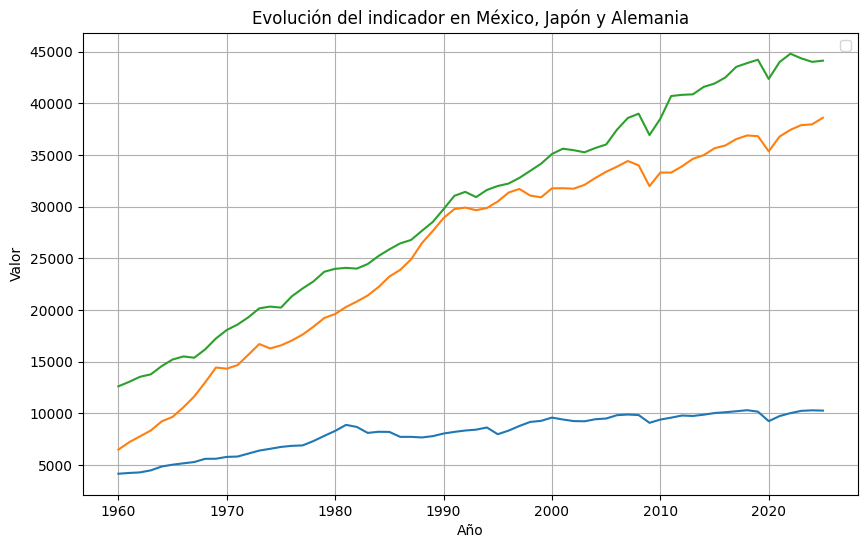

In [60]:
# Seleccionar 3 países
paises = ["Mexico", "Japan", "Germany"]

# Filtrar los datos
datos = df[df["entity"].isin(paises)].copy()

# Ordenar por año
datos = datos.sort_values("year")

# Crear gráfica
plt.figure(figsize=(10, 6))

for pais in paises:
    pais_df = datos[datos["entity"] == pais]
    plt.plot(
        pais_df["year"],
        pais_df["valor"]       
    )

# Título y etiquetas
plt.title("Evolución del indicador en México, Japón y Alemania")
plt.xlabel("Año")
plt.ylabel("Valor")
plt.legend()
plt.grid(True)

plt.show()

# Pregunta 9 — Visualización integradora
Crea dos gráficas de barras (horizontales o verticales) con el Top 10 de países según tu indicador en la primera consulta el año de tu nacimiento, y en la segunda el año 2023, ordenados de mayor a menor. Qué movimientos hubo en ambas gráficas? Agrega título y etiquetas de ejes.

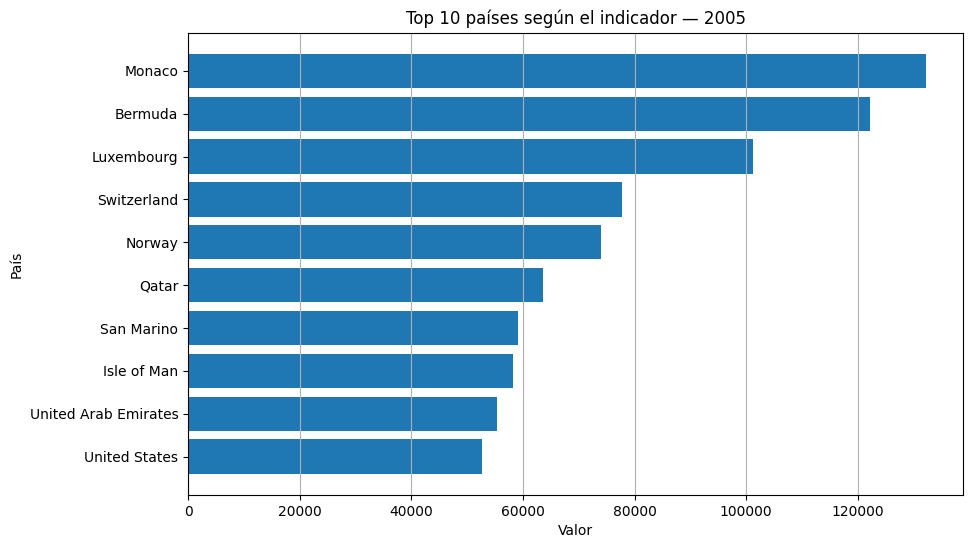

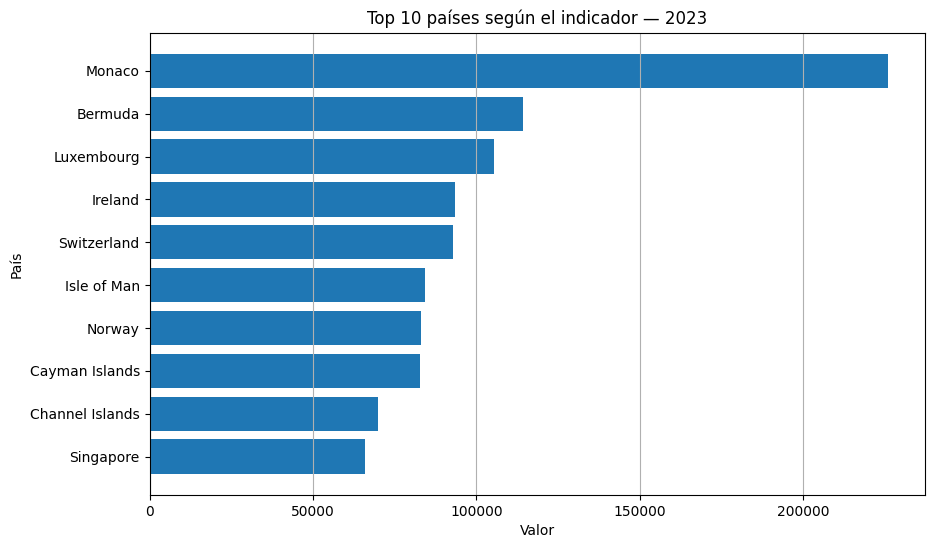

In [70]:
datos_2005 = df[df["year"] == 2005].copy()
datos_2023 = df[df["year"] == 2023].copy()

# Top 10 de cada año

top10_2005 = datos_2005.nlargest(10, "valor").sort_values("valor")
top10_2023 = datos_2023.nlargest(10, "valor").sort_values("valor")


plt.figure(figsize=(10, 6))

plt.barh(top10_2005["entity"], top10_2005["valor"])

plt.title("Top 10 países según el indicador — 2005")
plt.xlabel("Valor")
plt.ylabel("País")
plt.grid(axis="x")

plt.show()


plt.figure(figsize=(10, 6))

plt.barh(top10_2023["entity"], top10_2023["valor"])

plt.title("Top 10 países según el indicador — 2023")
plt.xlabel("Valor")
plt.ylabel("País")
plt.grid(axis="x")

plt.show()



# 5. Conclusión general
En 5 - 10 líneas, resume qué aprendiste sobre el dataset que te tocó trabajar: ¿qué patrones encontraste?, ¿qué limitaciones tiene la información (por ejemplo, valores absolutos sin normalizar por población, datos faltantes, etc.)?, ¿qué harías distinto si tuvieras más tiempo?

Durante el análisis del dataset aprendí a trabajar y comparar los valores de un indicador entre diferentes países y años.
Encontré que los valores presentan variaciones importantes entre países y que algunos muestran tendencias crecientes mientras otros presentan cambios fluctuantes.